In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

base_path = r"D:/sroie-ocr-ie"

ocr_text_folder = os.path.join(base_path, "data_ocr/train/Text")
entity_folder = os.path.join(base_path, "data/train/entities")

In [2]:
# Load OCR Text and Entities

records = []

files = sorted(os.listdir(entity_folder))   # iterate over ground truth files

for file in files:

    ocr_path = os.path.join(ocr_text_folder, file)
    entity_path = os.path.join(entity_folder, file)

    if not os.path.exists(ocr_path):
        continue

    with open(ocr_path, "r", encoding="utf-8") as f:
        ocr_data = json.load(f)

    with open(entity_path, "r", encoding="utf-8") as f:
        entities = json.load(f)

    company = entities.get("company","").lower()
    address = entities.get("address","").lower()
    date = entities.get("date","")
    total = entities.get("total","")

    for item in ocr_data:

        text = item["text"]
        box = item["bbox"]

        # PaddleOCR box format: 4 corner points
        xs = [p[0] for p in box]
        ys = [p[1] for p in box]

        x_center = sum(xs) / len(xs)
        y_center = sum(ys) / len(ys)

        text_clean = text.lower()

        label = "other"

        # total
        if total and total in text:
            label = "total"

        # date pattern
        elif re.search(r"\d{2}[/-]\d{2}[/-]\d{2,4}", text):
            label = "date"

        # company keyword match
        elif company and any(word in text_clean for word in company.split()):
            label = "company"

        # address keyword match
        elif address and any(word in text_clean for word in address.split()):
            label = "address"

        records.append({
            "file": file,
            "text": text,
            "label": label,
            "x_center": x_center,
            "y_center": y_center
        })

df = pd.DataFrame(records)

print("Receipts processed:", df["file"].nunique())
print(df["label"].value_counts())

Receipts processed: 626
label
other      25682
address     2475
total       1542
company     1395
date         754
Name: count, dtype: int64


In [3]:
# Normalize Layout Coordinates 
# (0,0) → top left
# (1,1) → bottom right

df["x_norm"] = (df["x_center"] - df["x_center"].min()) / (df["x_center"].max() - df["x_center"].min())
df["y_norm"] = (df["y_center"] - df["y_center"].min()) / (df["y_center"].max() - df["y_center"].min())

In [4]:
# Compute line position and normalize

df = df.sort_values(["file", "y_center"]).reset_index(drop=True)

df["line_index"] = df.groupby("file").cumcount()

df["line_norm"] = df.groupby("file")["line_index"].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)

print(df.head())

       file                        text    label  x_center  y_center  \
0  000.json               tan woon yann  company    196.25     44.75   
1  000.json  BOOK TA KTAMANDAYA)SDN BHD  company    246.00    103.00   
2  000.json                    789417-W    other    247.00    129.00   
3  000.json      NO.55557&59JALANSAGU18  address    245.50    154.00   
4  000.json                  TAMANDAYA,  company    245.00    177.50   

     x_norm    y_norm  line_index  line_norm  
0  0.055308  0.004293           0   0.000000  
1  0.070615  0.013068           1   0.023810  
2  0.070923  0.016985           2   0.047619  
3  0.070462  0.020751           3   0.071429  
4  0.070308  0.024291           4   0.095238  


In [5]:
df

,file,text,label,x_center,y_center,x_norm,y_norm,line_index,line_norm
0,000.json,tan woon yann,company,196.25,44.75,0.055308,0.004293,0,0.000000
1,000.json,BOOK TA KTAMANDAYA)SDN BHD,company,246.00,103.00,0.070615,0.013068,1,0.023810
2,000.json,789417-W,other,247.00,129.00,0.070923,0.016985,2,0.047619
3,000.json,NO.55557&59JALANSAGU18,address,245.50,154.00,0.070462,0.020751,3,0.071429
4,000.json,"TAMANDAYA,",company,245.00,177.50,0.070308,0.024291,4,0.095238
...,...,...,...,...,...,...,...,...,...
31843,625.json,0.68,other,461.00,780.50,0.136769,0.115128,37,0.902439
31844,625.json,11.32,other,343.00,781.00,0.100462,0.115204,38,0.926829
31845,625.json,Total,other,146.00,781.50,0.039846,0.115279,39,0.951220
31846,625.json,THANK YOU,other,301.00,819.00,0.087538,0.120928,40,0.975610


# Layout EDA

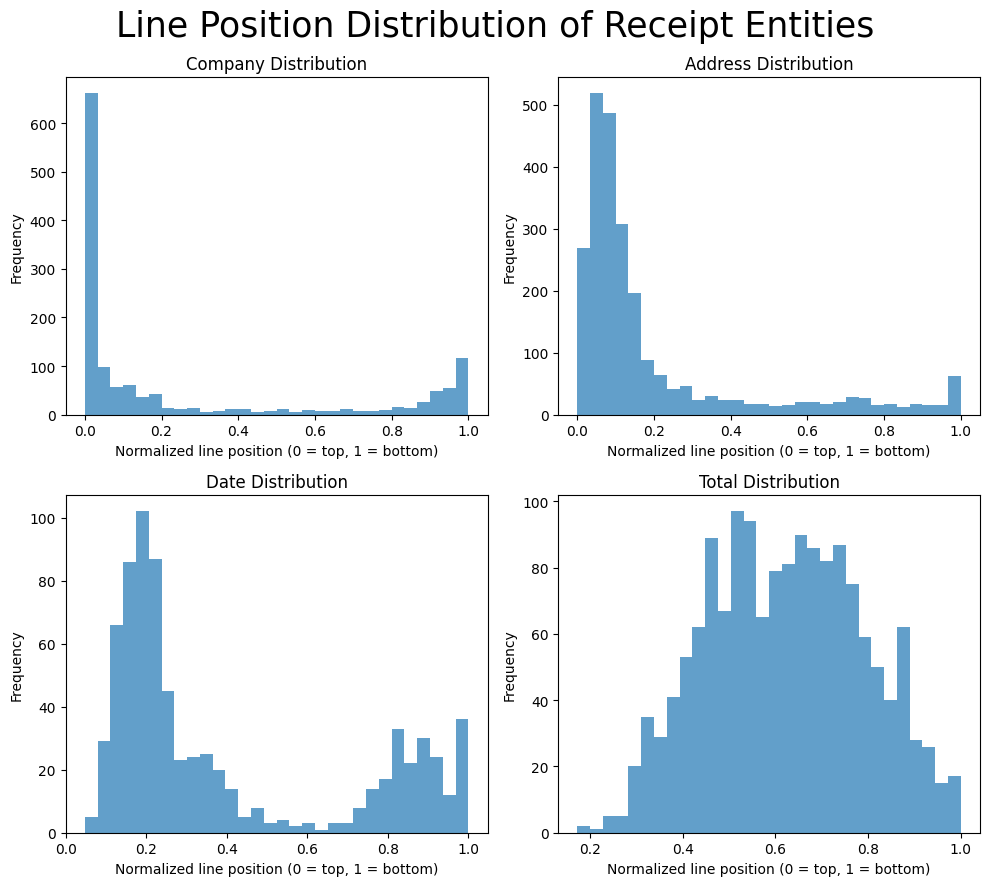

In [ ]:
import matplotlib.pyplot as plt

labels = ["company", "address", "date", "total"]

fig, axes = plt.subplots(2, 2, figsize=(10,9), sharex=False)

axes = axes.flatten()

for i, label in enumerate(labels):

    subset = df[df["label"] == label]

    axes[i].hist(subset["line_norm"], bins=30, alpha=0.7)

    axes[i].set_title(f"{label.capitalize()} Distribution")
    axes[i].set_xlabel("Normalized line position (0 = top, 1 = bottom)")
    axes[i].set_ylabel("Frequency")

fig.suptitle("Line Position Distribution of Receipt Entities", fontsize=25)
plt.tight_layout()
plt.show()

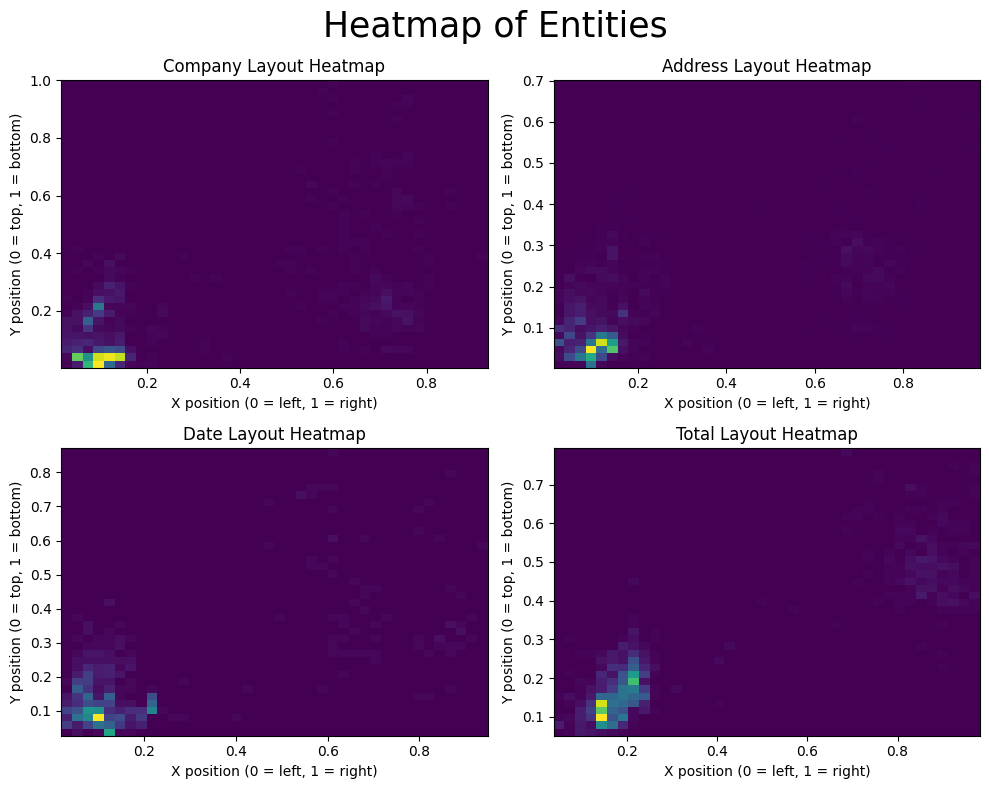

In [ ]:
import matplotlib.pyplot as plt

labels = ["company", "address", "date", "total"]

fig, axes = plt.subplots(2, 2, figsize=(10,8))

axes = axes.flatten()

for i, label in enumerate(labels):

    subset = df[df["label"] == label]

    axes[i].hist2d(
        subset["x_norm"],
        subset["y_norm"],
        bins=40
    )

    axes[i].set_title(f"{label.capitalize()} Layout Heatmap")
    axes[i].set_xlabel("X position (0 = left, 1 = right)")
    axes[i].set_ylabel("Y position (0 = top, 1 = bottom)")

fig.suptitle("Heatmap of Entities", fontsize=25)
plt.tight_layout()
plt.show()

# Text pattern EDA

In [12]:
from collections import Counter
import re

# Find keywords for each entities

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"[a-zA-Z0-9]+", text)
    return tokens


labels = ["company", "address", "date", "total"]

entity_keywords = {}

for label in labels:

    subset = df[df["label"] == label]

    words = []

    for text in subset["text"]:
        words.extend(tokenize(text))

    counter = Counter(words)

    keywords = [(w,c) for w,c in counter.most_common(100)]
    entity_keywords[label] = keywords


print(entity_keywords)

{'company': [('bhd', 356), ('sdn', 305), ('s', 84), ('gardenia', 82), ('aeon', 71), ('x', 70), ('com', 59), ('sanyu', 58), ('the', 57), ('i', 48), ('products', 48), ('stationery', 47), ('d', 46), ('fresh', 46), ('co', 45), ('makassar', 45), ('mr', 44), ('of', 44), ('facebook', 43), ('is', 42), ('market', 41), ('unihakka', 41), ('international', 41), ('kl', 41), ('bakeries', 38), ('no', 37), ('recipient', 36), ('k', 36), ('m', 35), ('follow', 35), ('y', 34), ('restaurant', 32), ('popular', 32), ('www', 32), ('139386', 32), ('usin', 32), ('restoran', 31), ('my', 31), ('1135772', 28), ('wan', 27), ('sheng', 27), ('perniagaan', 26), ('taman', 26), ('sanyustationeryshop', 26), ('h', 25), ('gst', 24), ('one', 24), ('total', 23), ('cash', 22), ('b519537', 22), ('be', 22), ('kee', 22), ('enterprise', 21), ('1', 21), ('syarikat', 21), ('hardware', 20), ('maluri', 20), ('gin', 20), ('tax', 19), ('supply', 19), ('sc', 18), ('a', 18), ('and', 18), ('b', 18), ('card', 17), ('trading', 17), ('permas

In [13]:
for entity in entity_keywords:
    print(f"===={entity}====")
    print(entity_keywords[entity])

====company====
[('bhd', 356), ('sdn', 305), ('s', 84), ('gardenia', 82), ('aeon', 71), ('x', 70), ('com', 59), ('sanyu', 58), ('the', 57), ('i', 48), ('products', 48), ('stationery', 47), ('d', 46), ('fresh', 46), ('co', 45), ('makassar', 45), ('mr', 44), ('of', 44), ('facebook', 43), ('is', 42), ('market', 41), ('unihakka', 41), ('international', 41), ('kl', 41), ('bakeries', 38), ('no', 37), ('recipient', 36), ('k', 36), ('m', 35), ('follow', 35), ('y', 34), ('restaurant', 32), ('popular', 32), ('www', 32), ('139386', 32), ('usin', 32), ('restoran', 31), ('my', 31), ('1135772', 28), ('wan', 27), ('sheng', 27), ('perniagaan', 26), ('taman', 26), ('sanyustationeryshop', 26), ('h', 25), ('gst', 24), ('one', 24), ('total', 23), ('cash', 22), ('b519537', 22), ('be', 22), ('kee', 22), ('enterprise', 21), ('1', 21), ('syarikat', 21), ('hardware', 20), ('maluri', 20), ('gin', 20), ('tax', 19), ('supply', 19), ('sc', 18), ('a', 18), ('and', 18), ('b', 18), ('card', 17), ('trading', 17), ('pe

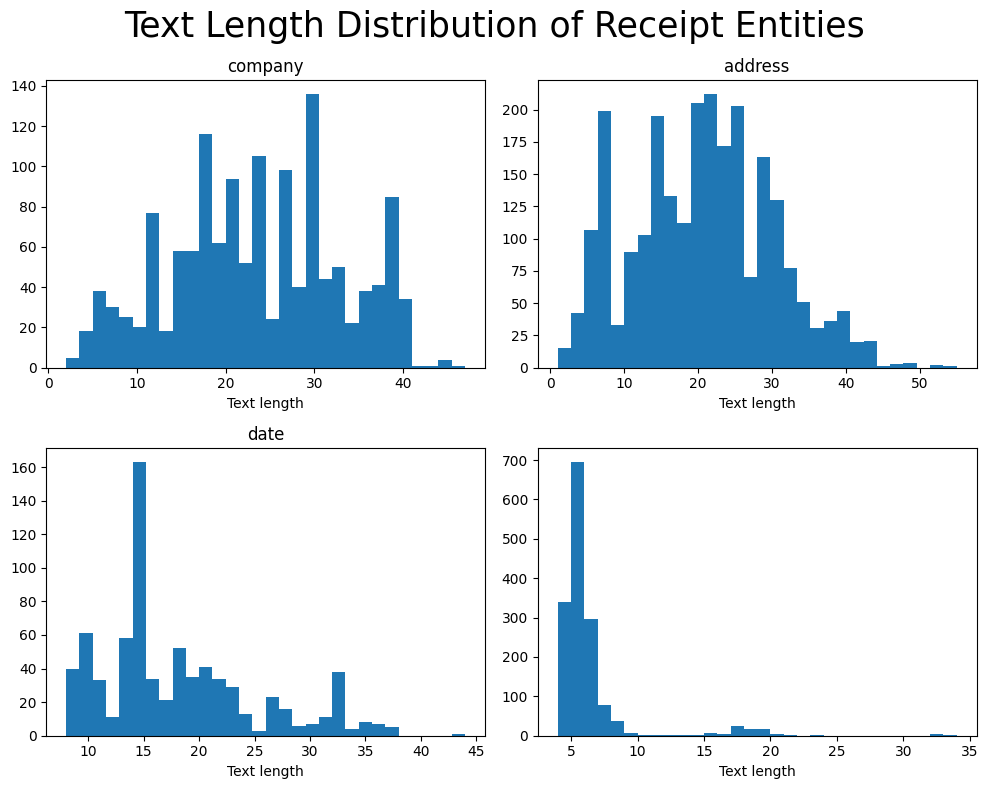

In [34]:
# Text length distribution

df["text_length"] = df["text"].str.len()

import matplotlib.pyplot as plt

labels = ["company","address","date","total"]

fig, axes = plt.subplots(2,2, figsize=(10,8))
axes = axes.flatten()

for i,label in enumerate(labels):

    subset = df[df["label"] == label]

    axes[i].hist(subset["text_length"], bins=30)

    axes[i].set_title(label)
    axes[i].set_xlabel("Text length")

fig.suptitle("Text Length Distribution of Receipt Entities", fontsize=25)
plt.title("")
plt.tight_layout()
plt.show()

In [23]:
import re
import pandas as pd

def pattern_stats(label):

    subset = df[df["label"] == label]["text"].dropna()

    stats = []

    for text in subset:

        stats.append({
            "digits": bool(re.search(r"\d", text)),
            "letters": bool(re.search(r"[A-Za-z]", text)),
            "symbols": bool(re.search(r"[^\w\s]", text)),
            "length": len(text)
        })

    return pd.DataFrame(stats).mean()


for label in ["company","address","date","total"]:

    print("\n",label)
    print(pattern_stats(label))


 company
digits      0.287455
letters     0.994265
symbols     0.524014
length     23.292473
dtype: float64

 address
digits      0.728081
letters     0.955152
symbols     0.711111
length     20.544242
dtype: float64

 date
digits      1.000000
letters     0.688329
symbols     1.000000
length     18.075597
dtype: float64

 total
digits     1.000000
letters    0.178988
symbols    1.000000
length     5.918936
dtype: float64


In [ ]:
# Date format
dates = df[df["label"] == "date"]["text"].dropna().unique()

for d in dates[:30]:
    print(d)

25/12/20188:13:39PM
19/10/2018
12-01-1921:13SH01ZK09
Date.25/12/2018
PI12PJ11-46/300
18-11-18 13:58SH01ZI53
Date09/01/20198:0111PM
Date:11/01/2019
23-01-2019 13:14:15 PMPRINT BY:r0ot
Date:12/02/2018
ORD#50-REG#19-18/01/201810:27:03
Frid-y29-12-2017 Time :20:17
RECEIPT#CSP0393921 0ATE15/06/201
22/12/201714:03
12/28/201710:17:32PM
2017-12-2822:17PM
Date: 22/12/2017
Bil1 Date:20/12/2017
Bil1Start:20/12/201707:10:35PM
Closed Bi11:20/12/2017 07:10:51PM
Bil1 Date :20/11/2017
Bi11 Start:20/11/2017 03:55:07PM
ClosBi11:20/11/2017 03:55:56 PM
18/03/1815:170605102
06/03/2018
18/01/2018
NO43-45-47G
25/01/20181:22:56PM
Date17/01/2018
Receipt No.CS1801/26717Date15/01/2018


In [ ]:
DATE_PATTERN = r"\b(\d{1,2}[/-]\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2}[/-]\d{1,2})\b"

## Token Count per Entity

In [24]:
df["token_count"] = df["text"].apply(lambda x: len(tokenize(x)))

for label in labels:

    subset = df[df["label"]==label]

    print(label, subset["token_count"].describe())

company count    1395.000000
mean        3.930466
std         1.786739
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: token_count, dtype: float64
address count    2475.000000
mean        3.456162
std         1.722221
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: token_count, dtype: float64
date count    754.000000
mean       4.522546
std        1.421761
min        3.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       10.000000
Name: token_count, dtype: float64
total count    1542.000000
mean        2.133593
std         0.502092
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         7.000000
Name: token_count, dtype: float64


# Rule-based system

In [1]:
import os
import re
import pandas as pd
from pathlib import Path

In [2]:
BASE_PATH = Path(r"D:\sroie-ocr-ie\data\test")

TEST_BOX = BASE_PATH / "box"        # OCR txt
TEST_IMG = BASE_PATH / "img"        # images
TEST_ENT = BASE_PATH / "entities"   # ground truth

In [3]:
records = []

for file in os.listdir(TEST_BOX):

    if not file.endswith(".txt"):
        continue

    file_path = TEST_BOX / file

    with open(file_path, "r", encoding="latin-1") as f:

        for line in f:

            line = line.strip()

            if line == "":
                continue

            parts = line.split(",")

            if len(parts) < 9:
                continue

            try:
                coords = list(map(int, parts[:8]))
            except:
                continue

            text = ",".join(parts[8:])
            text = re.sub(r"\s+", " ", text).strip()

            xs = coords[0::2]
            ys = coords[1::2]

            x_center = sum(xs) / 4
            y_center = sum(ys) / 4

            records.append({
                "file": file,
                "text": text,
                "x_center": x_center,
                "y_center": y_center
            })

df = pd.DataFrame(records)

print("Receipts:", df["file"].nunique())
print("Lines:", len(df))

Receipts: 347
Lines: 18705


In [4]:
df["x_norm"] = (df["x_center"] - df["x_center"].min()) / (df["x_center"].max() - df["x_center"].min())

df["y_norm"] = (df["y_center"] - df["y_center"].min()) / (df["y_center"].max() - df["y_center"].min())

In [5]:
df = df.sort_values(["file","y_center"]).reset_index(drop=True)

df["line_index"] = df.groupby("file").cumcount()

df["line_norm"] = df.groupby("file")["line_index"].transform(
    lambda x: x / x.max() if x.max() > 0 else 0
)

In [6]:
def compute_text_features(text):

    letters = len(re.findall(r"[A-Za-z]", text))
    digits = len(re.findall(r"[0-9]", text))
    symbols = len(re.findall(r"[^A-Za-z0-9\s]", text))

    length = len(text)

    if length == 0:
        return pd.Series([0,0,0,0])

    return pd.Series([
        letters/length,
        digits/length,
        symbols/length,
        length
    ])

df[["letters_ratio","digits_ratio","symbols_ratio","text_length"]] = df["text"].apply(compute_text_features)

df["token_count"] = df["text"].apply(lambda x: len(x.split()))

In [7]:
DATE_PATTERNS = [
    r"\d{1,2}[/-]\d{1,2}[/-]\d{2,4}",
    r"\d{4}-\d{2}-\d{2}"
]

PRICE_PATTERN = r"\d+\.\d{2}"

ADDRESS_KEYWORDS = [
    "jalan","street","road","taman","bandar",
    "kuala","selangor","johor","lot","no"
]


def extract_price(text):

    m = re.search(PRICE_PATTERN, text)

    if m:
        return float(m.group())

    return None

In [8]:
def extract_receipt(receipt_df):

    receipt_df = receipt_df.copy()

    # DATE
    date = None

    for text in receipt_df["text"]:

        for p in DATE_PATTERNS:
            if re.search(p, text):
                date = text
                break

        if date:
            break


    # TOTAL
    price_lines = receipt_df[
        receipt_df["text"].str.contains(PRICE_PATTERN, regex=True)
    ].copy()

    price_lines["price"] = price_lines["text"].apply(extract_price)

    bottom_prices = price_lines[
        (price_lines["line_norm"] > 0.6) &
        (price_lines["x_norm"] > 0.4)
    ]

    if len(bottom_prices) > 0:
        total = bottom_prices.sort_values("price", ascending=False).iloc[0]["text"]
    else:
        total = price_lines.sort_values("price", ascending=False).iloc[0]["text"]


    # COMPANY
    top_lines = receipt_df.sort_values("line_norm").head(5)

    company = top_lines.iloc[0]["text"]


    # ADDRESS
    address_candidates = receipt_df[
        receipt_df["text"].str.contains("|".join(ADDRESS_KEYWORDS), case=False, regex=True)
    ]

    if len(address_candidates) > 0:
        address = address_candidates.iloc[0]["text"]
    else:
        address = None


    return {
        "company": company,
        "address": address,
        "date": date,
        "total": total
    }

In [9]:
df

,file,text,x_center,y_center,x_norm,y_norm,line_index,line_norm,letters_ratio,digits_ratio,symbols_ratio,text_length,token_count
0,000.txt,TAN CHAY YEE,209.5,46.0,0.052970,0.005212,0,0.000000,0.833333,0.000000,0.000000,12.0,3
1,000.txt,*** COPY ***,208.5,107.5,0.052678,0.014370,1,0.021739,0.333333,0.000000,0.500000,12.0,3
2,000.txt,OJC MARKETING SDN BHD,204.5,129.5,0.051507,0.017646,2,0.043478,0.857143,0.000000,0.000000,21.0,4
3,000.txt,ROC NO: 538358-H,208.0,151.0,0.052531,0.020847,3,0.065217,0.375000,0.375000,0.125000,16.0,3
4,000.txt,"NO 2 & 4, JALAN BAYU 4,",205.0,172.5,0.051653,0.024049,4,0.086957,0.478261,0.130435,0.130435,23.0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18700,346.txt,9.81,376.5,1469.0,0.101844,0.217110,48,0.923077,0.000000,0.750000,0.250000,4.0,1
18701,346.txt,0.59,553.0,1470.0,0.153497,0.217259,49,0.942308,0.000000,0.750000,0.250000,4.0,1
18702,346.txt,10.40,747.0,1470.0,0.210272,0.217259,50,0.961538,0.000000,0.800000,0.200000,5.0,1
18703,346.txt,THANK YOU ! & PLEASE COME AGAIN !!,416.0,1559.5,0.113404,0.230586,51,0.980769,0.676471,0.000000,0.117647,34.0,8


In [10]:
results = {}

for receipt in df["file"].unique():

    receipt_df = df[df["file"] == receipt]

    results[receipt] = extract_receipt(receipt_df)

In [11]:
results

{'000.txt': {'company': 'TAN CHAY YEE',
  'address': 'ROC NO: 538358-H',
  'date': ': 15/01/2019 11:05:16 AM',
  'total': '193.00'},
 '001.txt': {'company': 'TAN CHAY YEE',
  'address': 'ROC NO: 538358-H',
  'date': '02/01/2019 2:47:14 PM',
  'total': '170.00'},
 '002.txt': {'company': 'PERNIAGAAN ZHENG HUI',
  'address': 'NO.59 JALAN PERMAS 9/5',
  'date': 'DATE:09/02/2018',
  'total': '436.20'},
 '003.txt': {'company': 'PETRON BKT LANJAN SB',
  'address': 'CO NO: 001083069-M',
  'date': '01/02/2018',
  'total': 'A=6.00%'},
 '004.txt': {'company': '190',
  'address': 'FORMERLY KNOWN AS',
  'date': 'ORD #90 -REG #19- 18/01/2018 17:09:21',
  'total': '50.00'},
 '005.txt': {'company': 'SIN LIANHAP SDN BHD',
  'address': 'LOT 13, JALAN',
  'date': ':05/02/2018',
  'total': '7.30'},
 '006.txt': {'company': 'CROSS CHANNEL NETWORK SDN. BHD.',
  'address': '47,JALAN MERANTI 1, SEK. 3,',
  'date': '29/01/2018 4:40:40 PM',
  'total': '10.00'},
 '007.txt': {'company': 'CROSS CHANNEL NETWORK SDN.

In [13]:
import json

# Load Ground Truth
fields = ["company", "date", "address", "total"]

ground_truths = {}

for file in os.listdir(TEST_ENT):

    if not file.endswith(".json"):
        continue

    with open(TEST_ENT / file, "r", encoding="utf-8") as f:
        data = json.load(f)

    file_id = file.replace(".json", ".txt")

    ground_truths[file_id] = {
        "company": data.get("company", ""),
        "date": data.get("date", ""),
        "address": data.get("address", ""),
        "total": data.get("total", "")
    }

In [14]:
predictions = {}

for file_id, pred in results.items():

    text = (
        f"<s_company>{pred.get('company','')}</s_company>"
        f"<s_address>{pred.get('address','')}</s_address>"
        f"<s_date>{pred.get('date','')}</s_date>"
        f"<s_total>{pred.get('total','')}</s_total>"
    )

    predictions[file_id] = text

In [15]:
def parse_donut_output(text):

    result = {}

    for f in fields:
        pattern = f"<s_{f}>(.*?)</s_{f}>"
        match = re.search(pattern, text)

        if match:
            result[f] = match.group(1).strip()
        else:
            result[f] = ""

    return result

In [16]:
def normalize(x):
    return str(x).lower().strip()

In [17]:
!pip install python-Levenshtein


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Users\hana2\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
import Levenshtein

In [19]:
correct = 0
total_pred = 0
total_gt = 0

field_correct = {f:0 for f in fields}
field_total = {f:0 for f in fields}

lev_scores = []

for file_id in predictions:

    if file_id not in ground_truths:
        continue

    pred_text = predictions[file_id]
    gt = ground_truths[file_id]

    pred = parse_donut_output(pred_text)

    for f in fields:

        p = normalize(pred.get(f,""))
        g = normalize(gt.get(f,""))

        field_total[f] += 1

        if p == g:
            field_correct[f] += 1
            correct += 1

        total_pred += 1
        total_gt += 1

        if len(p) > 0 or len(g) > 0:
            sim = 1 - Levenshtein.distance(p,g) / max(len(p),len(g))
            lev_scores.append(sim)

In [20]:
precision = correct / total_pred
recall = correct / total_gt
f1 = 2 * precision * recall / (precision + recall)

print("===== Field Accuracy =====")

for f in fields:
    acc = field_correct[f] / field_total[f]
    print(f"{f}: {acc:.3f}")

print("\n===== Entity Metrics =====")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

print("\n===== Levenshtein Similarity =====")
print(f"Average Similarity: {sum(lev_scores)/len(lev_scores):.3f}")

===== Field Accuracy =====
company: 0.542
date: 0.156
address: 0.009
total: 0.418

===== Entity Metrics =====
Precision: 0.281
Recall: 0.281
F1 Score: 0.281

===== Levenshtein Similarity =====
Average Similarity: 0.584


In [21]:
def print_extraction_comparison(predictions, ground_truths):

    for file_id in predictions:

        if file_id not in ground_truths:
            continue

        pred = parse_donut_output(predictions[file_id])
        gt = ground_truths[file_id]

        print("\n" + "="*60)
        print("FILE:", file_id)
        print("="*60)

        for f in fields:

            p = normalize(pred.get(f,""))
            g = normalize(gt.get(f,""))

            status = "✓" if p == g else "✗"

            print(f"{f.upper():8} | Pred: {p}")
            print(f"{'':8} | GT  : {g}")
            print(f"{'':8} | Match: {status}")
            print("-"*60)

In [23]:
print_extraction_comparison(predictions, ground_truths)


FILE: 000.txt
COMPANY  | Pred: tan chay yee
         | GT  : ojc marketing sdn bhd
         | Match: ✗
------------------------------------------------------------
DATE     | Pred: : 15/01/2019 11:05:16 am
         | GT  : 15/01/2019
         | Match: ✗
------------------------------------------------------------
ADDRESS  | Pred: roc no: 538358-h
         | GT  : no 2 & 4, jalan bayu 4, bandar seri alam, b1750 masai, johor
         | Match: ✗
------------------------------------------------------------
TOTAL    | Pred: 193.00
         | GT  : 193.00
         | Match: ✓
------------------------------------------------------------

FILE: 001.txt
COMPANY  | Pred: tan chay yee
         | GT  : ojc marketing sdn bhd
         | Match: ✗
------------------------------------------------------------
DATE     | Pred: 02/01/2019 2:47:14 pm
         | GT  : 02/01/2019
         | Match: ✗
------------------------------------------------------------
ADDRESS  | Pred: roc no: 538358-h
         | GT  